                     generation_mw  demand_mw  load_shedding  gas  \
datetime                                                            
2015-04-19 00:00:00         4821.0       4821              0    0   
2015-04-19 01:00:00         3612.0       3612              0    0   
2015-04-19 02:00:00         3727.0       3727              0    0   
2015-04-19 03:00:00         3632.0       3632              0    0   
2015-04-19 04:00:00         3641.0       3641              0    0   

                     liquid_fuel  coal  hydro  solar  wind  \
datetime                                                     
2015-04-19 00:00:00            0     0      0    0.0   0.0   
2015-04-19 01:00:00            0     0      0    0.0   0.0   
2015-04-19 02:00:00            0     0      0    0.0   0.0   
2015-04-19 03:00:00            0     0      0    0.0   0.0   
2015-04-19 04:00:00            0     0      0    0.0   0.0   

                     india_bheramara_hvdc  ...  india_adani  nepal  remarks  \
da

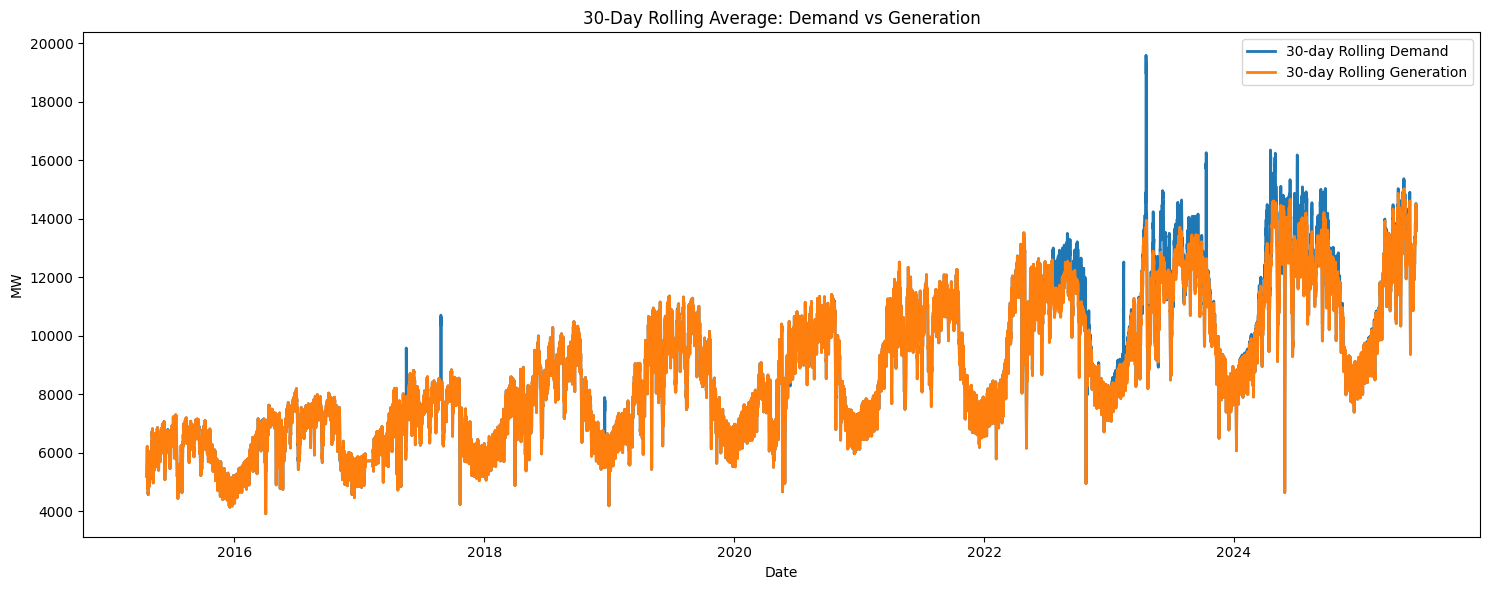

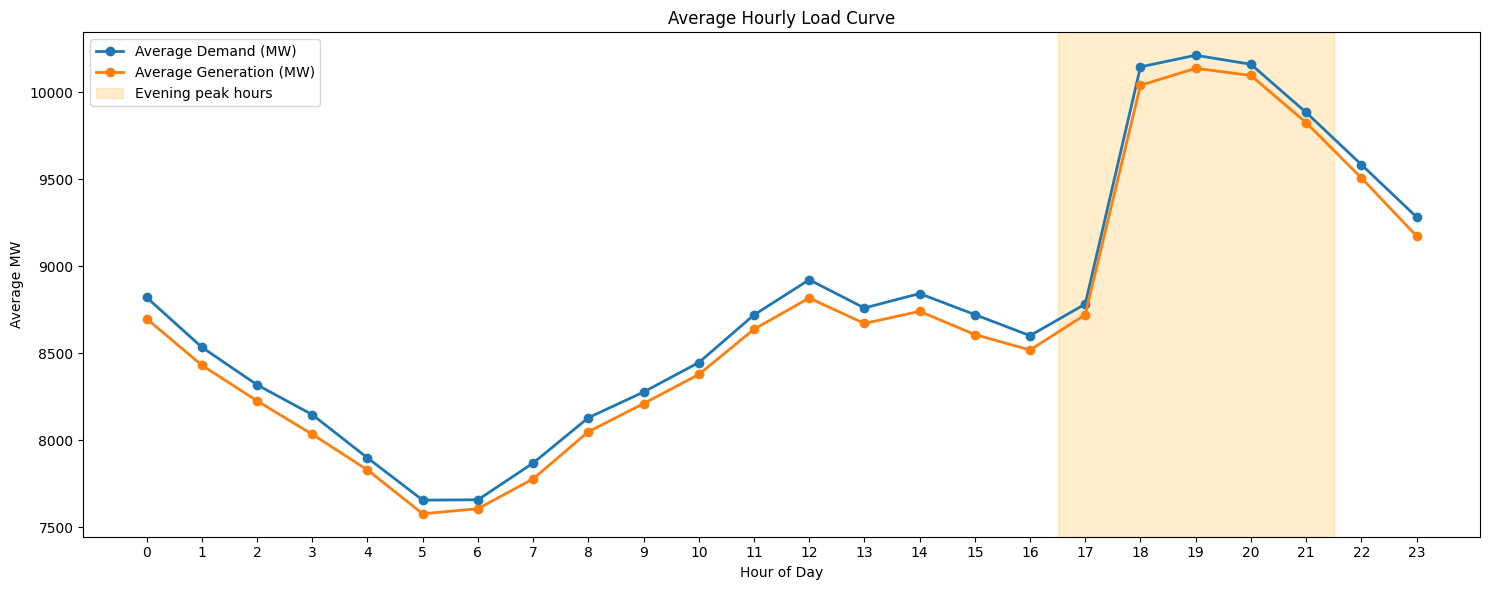

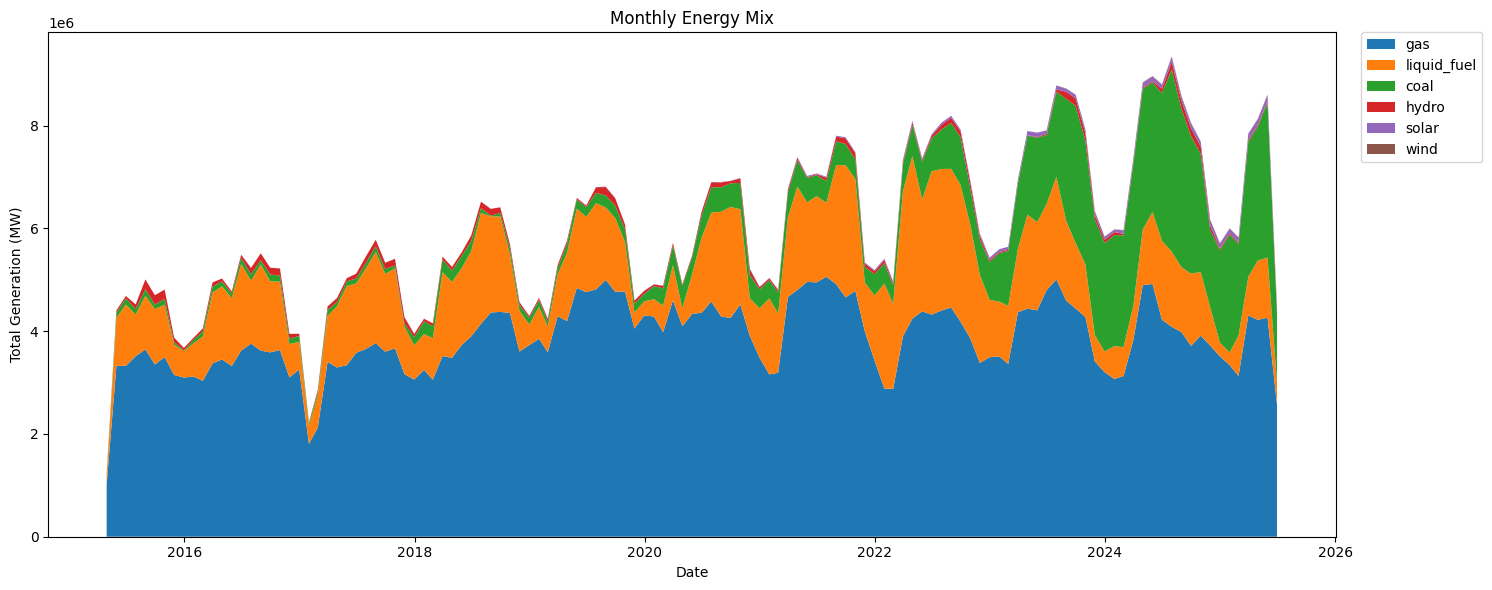

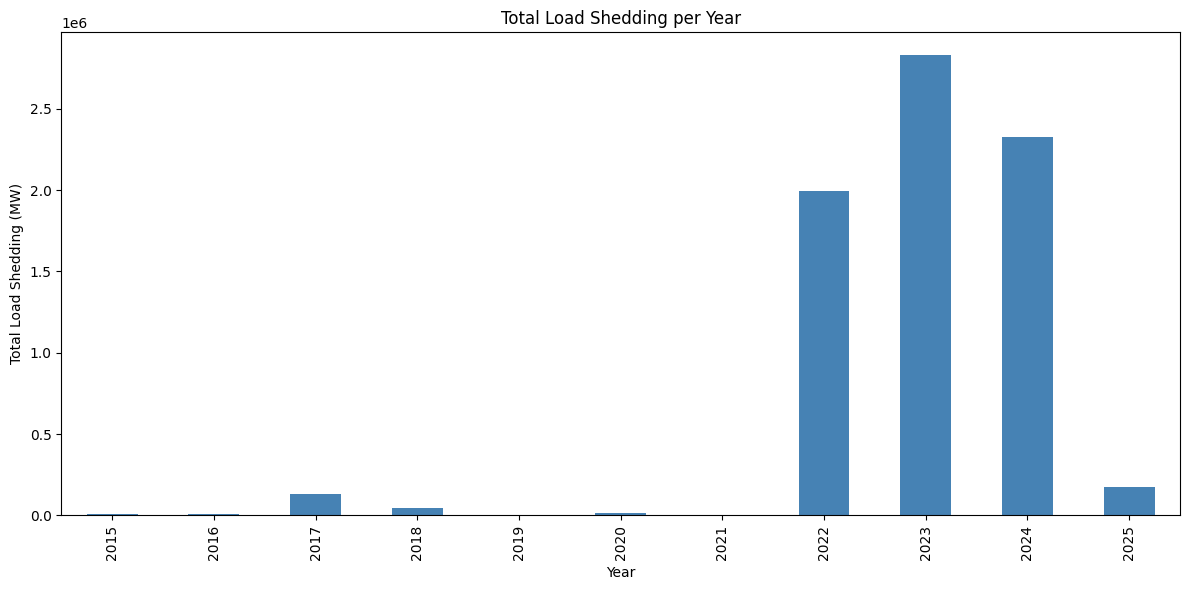

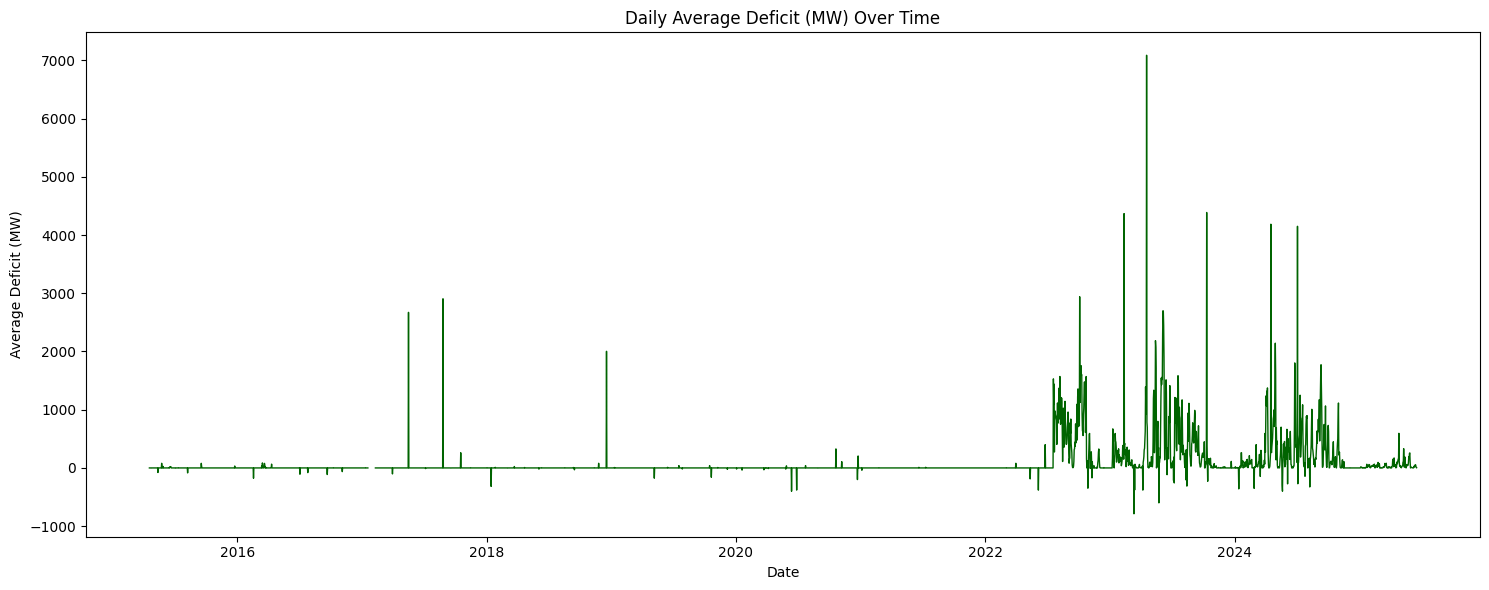

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'PGCB_cleaned_power_data.csv'
df = pd.read_csv(file_path, parse_dates=['datetime'], index_col='datetime')

print(df.head())

rolling_window = 30
rolling_df = df[['demand_mw', 'generation_mw']].rolling(window=rolling_window).mean()

plt.figure(figsize=(15, 6))
plt.plot(rolling_df.index, rolling_df['demand_mw'], label='30-day Rolling Demand', linewidth=2)
plt.plot(rolling_df.index, rolling_df['generation_mw'], label='30-day Rolling Generation', linewidth=2)

plt.title('30-Day Rolling Average: Demand vs Generation')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

# Hourly average daily load curve
if 'Hour' not in df.columns:
    df['Hour'] = df.index.hour

hourly_avg = df.groupby('Hour')[['demand_mw', 'generation_mw']].mean()

plt.figure(figsize=(15, 6))
plt.plot(hourly_avg.index, hourly_avg['demand_mw'], marker='o', label='Average Demand (MW)', linewidth=2)
plt.plot(hourly_avg.index, hourly_avg['generation_mw'], marker='o', label='Average Generation (MW)', linewidth=2)

# Highlight typical evening peak hours
evening_peak = range(17, 22)
plt.axvspan(min(evening_peak) - 0.5, max(evening_peak) + 0.5, color='orange', alpha=0.2, label='Evening peak hours')

plt.title('Average Hourly Load Curve')
plt.xlabel('Hour of Day')
plt.ylabel('Average MW')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

energy_cols = ['gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind']
monthly_energy = df[energy_cols].resample('ME').sum()

palette = sns.color_palette('tab10', n_colors=len(energy_cols))

plt.figure(figsize=(15, 6))
plt.stackplot(monthly_energy.index, [monthly_energy[col] for col in energy_cols], labels=energy_cols, colors=palette)

plt.title('Monthly Energy Mix')
plt.xlabel('Date')
plt.ylabel('Total Generation (MW)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Total load shedding per year
if 'Year' not in df.columns:
    df['Year'] = df.index.year

yearly_load_shedding = df.groupby('Year')['load_shedding'].sum()

plt.figure(figsize=(12, 6))
yearly_load_shedding.plot(kind='bar', color='steelblue')
plt.title('Total Load Shedding per Year')
plt.xlabel('Year')
plt.ylabel('Total Load Shedding (MW)')
plt.tight_layout()
plt.show()

daily_deficit = df['deficit_mw'].resample('D').mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_deficit.index, daily_deficit, color='darkgreen', linewidth=1)
plt.title('Daily Average Deficit (MW) Over Time')
plt.xlabel('Date')
plt.ylabel('Average Deficit (MW)')
plt.tight_layout()
plt.show()